
""
XGBoost + SHAP análisis de patrones histológicos vs mutaciones genéticas
EGFR, TP53, KEAP1, NF1, STK11

Entrada:
  /home/rapids/notebooks/slima/MAF/cohortMAF.2025-11-16_with_histologic_patterns.csv
    (CSV separado por punto y coma)

Salida (por defecto):
  /home/rapids/notebooks/slima/MAF/xgb_results/
""


In [1]:

import os
from pathlib import Path
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

import xgboost as xgb
import shap


In [2]:

# -------------------------------------------------------------------
# Config global
# -------------------------------------------------------------------

MUT_GENES = ["EGFR", "TP53", "KEAP1", "NF1", "STK11"]

HISTO_COLS = [
    "n_tiles_total",
    "pct_acinar",
    "pct_lepidic",
    "pct_micropapillary",
    "pct_mucinous",
    "pct_papillary",
    "pct_solid",
]



In [3]:

# -------------------------------------------------------------------
# Carga de datos
# -------------------------------------------------------------------

def read_maf_with_histology(path: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Lee el CSV (separado por ',') con la información MAF cruda + patrones histológicos.

    Devuelve:
      df_all   : tabla completa (todas las variantes)
      df_histo : una fila por caso (case_barcode) con columnas histológicas agregadas
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"No existe el archivo: {path}")

    # Importante: separador punto y coma
    df_all = pd.read_csv(path, sep=",")

    required_cols = ["case_barcode"] + HISTO_COLS
    missing = [c for c in required_cols if c not in df_all.columns]
    if missing:
        raise ValueError(f"Faltan columnas en el CSV: {missing}")

    # Nos quedamos con columnas histológicas + case_barcode
    df_histo = df_all[required_cols].copy()

    # Puede haber filas repetidas por cada mutación; agregamos por caso
    df_histo = (
        df_histo.groupby("case_barcode", as_index=False)
        .agg("first")
    )

    # Asegurar numéricos en histo
    for col in HISTO_COLS:
        df_histo[col] = pd.to_numeric(df_histo[col], errors="coerce")

    df_histo[HISTO_COLS] = df_histo[HISTO_COLS].fillna(0.0)

    return df_all, df_histo


In [4]:

# # -------------------------------------------------------------------
# # Construcción dataset por gen
# # -------------------------------------------------------------------

# def build_case_level_dataset_for_gene(
#     df_all: pd.DataFrame,
#     df_histo: pd.DataFrame,
#     gene: str,
# ) -> pd.DataFrame:
#     """
#     Construye un dataset a nivel caso para un gen concreto:

#       X: columnas histológicas (HISTO_COLS)
#       y: 1 si el caso tiene al menos una mutación en 'gene', 0 si no

#     Devuelve un DataFrame con:
#       case_barcode, y, HISTO_COLS...
#     """
#     # Casos mutados para ese gen
#     mut_cases = set(
#         df_all.loc[df_all["Hugo_Symbol"] == gene, "case_barcode"].dropna().unique()
#     )

#     df = df_histo.copy()
#     df["y"] = df["case_barcode"].isin(mut_cases).astype(int)

#     return df


In [5]:


# Sólo las columnas de patrones (sin n_tiles_tot)
HISTO_PATTERN_COLS = [c for c in HISTO_COLS if c != "n_tiles_tot"]


# -------------------------------------------------------------------
# Construcción dataset por gen (filtrando casos sin histología)
# -------------------------------------------------------------------
def build_case_level_dataset_for_gene(
    df_all: pd.DataFrame,
    df_histo: pd.DataFrame,
    gene: str,
) -> pd.DataFrame:
    """
    Construye un dataset a nivel caso para un gen concreto:

      X: columnas histológicas (HISTO_COLS)
      y: 1 si el caso tiene al menos una mutación en 'gene', 0 si no

    Se EXCLUYEN los casos cuyo vector de patrones histológicos
    (HISTO_PATTERN_COLS) es todo ceros.

    Devuelve un DataFrame con:
      case_barcode, y, HISTO_COLS...
    """
    # Casos mutados para ese gen
    mut_cases = set(
        df_all.loc[df_all["Hugo_Symbol"] == gene, "case_barcode"]
             .dropna()
             .unique()
    )

    df = df_histo.copy()
    # Etiqueta: mutado (1) / no mutado (0)
    df["y"] = df["case_barcode"].isin(mut_cases).astype(int)

    # --- Filtrar casos sin información histológica útil ---
    # Definimos "sin histología" = todas las columnas de patrones en cero
    # (acinar, lepidic, micropapillary, etc.)
    before = len(df)
    # Aseguramos que las columnas existan
    cols_present = [c for c in HISTO_PATTERN_COLS if c in df.columns]
    if not cols_present:
        raise ValueError(
            f"No se encontraron columnas de patrones histológicos en df_histo para {gene}: "
            f"esperaba alguna de {HISTO_PATTERN_COLS}"
        )

    # Fila con al menos un patrón > 0
    mask_has_pattern = (df[cols_present].abs().sum(axis=1) > 0)

    df = df[mask_has_pattern].reset_index(drop=True)
    after = len(df)

    print(
        f"[{gene}] Casos totales en histo_per_case: {before} -> "
        f"{after} tras filtrar casos sin patrones histológicos (todo cero)."
    )

    return df


In [6]:



# -------------------------------------------------------------------
# Entrenamiento XGBoost + SHAP para un gen
# -------------------------------------------------------------------

def run_xgb_for_gene(
    gene: str,
    df_all: pd.DataFrame,
    df_histo: pd.DataFrame,
    out_dir: Path,
    test_size: float = 0.30,
    random_state: int = 42,
    min_positive: int = 5,
) -> Dict[str, float]:
    """
    Entrena un XGBoost binario para predecir mutación (sí/no) en 'gene'
    usando como features los patrones histológicos.

    Guarda:
      - xgb_metrics_<GENE>.csv
      - xgb_importances_<GENE>.csv
      - shap_values_<GENE>.csv
      - shap_summary_<GENE>.csv
      - xgb_model_<GENE>.json

    Devuelve un dict con métricas.
    """
    out_dir.mkdir(parents=True, exist_ok=True)

    df_gene = build_case_level_dataset_for_gene(df_all, df_histo, gene)
    X = df_gene[HISTO_COLS].values
    y = df_gene["y"].values
    cases = df_gene["case_barcode"].values

    n_pos = int(y.sum())
    n_neg = int((1 - y).sum())
    print(f"[{gene}] Casos totales={len(y)}, positivos={n_pos}, negativos={n_neg}")

    if n_pos < min_positive:
        print(f"[{gene}] Menos de {min_positive} positivos. Se omite modelo.")
        return {
            "gene": gene,
            "n_cases": len(y),
            "n_pos": n_pos,
            "n_neg": n_neg,
            "auc": np.nan,
            "accuracy": np.nan,
            "f1": np.nan,
            "precision": np.nan,
            "recall": np.nan,
        }

    X_train, X_test, y_train, y_test, cases_train, cases_test = train_test_split(
        X,
        y,
        cases,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    # Balanceo simple
    scale_pos_weight = float(n_neg) / float(n_pos) if n_pos > 0 else 1.0

    model = xgb.XGBClassifier(
        objective="binary:logistic",
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        reg_alpha=0.0,
        n_jobs=4,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        tree_method="hist",
        random_state=random_state,
    )

    model.fit(X_train, y_train)

    # Predicciones
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    # Métricas
    try:
        auc = roc_auc_score(y_test, y_proba)
    except ValueError:
        auc = np.nan

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)

    metrics = {
        "gene": gene,
        "n_cases": len(y),
        "n_pos": n_pos,
        "n_neg": n_neg,
        "auc": auc,
        "accuracy": acc,
        "f1": f1,
        "precision": prec,
        "recall": rec,
    }

    # Guardar métricas
    metrics_path = out_dir / f"xgb_metrics_{gene}.csv"
    pd.DataFrame([metrics]).to_csv(metrics_path, index=False)
    print(f"[{gene}] Métricas guardadas en {metrics_path}")

    # Importancia de features (gain)
    importances = model.feature_importances_
    df_imp = pd.DataFrame(
        {"feature": HISTO_COLS, "importance": importances}
    ).sort_values("importance", ascending=False)
    imp_path = out_dir / f"xgb_importances_{gene}.csv"
    df_imp.to_csv(imp_path, index=False)
    print(f"[{gene}] Importancias guardadas en {imp_path}")

    # Guardar modelo
    model_path = out_dir / f"xgb_model_{gene}.json"
    model.save_model(model_path)
    print(f"[{gene}] Modelo XGBoost guardado en {model_path}")

    # --- SHAP ---

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)  # sobre todos los casos

    # SHAP por caso
    df_shap = pd.DataFrame(shap_values, columns=HISTO_COLS)
    df_shap.insert(0, "case_barcode", cases)
    shap_values_path = out_dir / f"shap_values_{gene}.csv"
    df_shap.to_csv(shap_values_path, index=False)
    print(f"[{gene}] Valores SHAP por caso guardados en {shap_values_path}")

    # SHAP resumen global (|SHAP| medio)
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    df_shap_summary = pd.DataFrame(
        {"feature": HISTO_COLS, "mean_abs_shap": mean_abs_shap}
    ).sort_values("mean_abs_shap", ascending=False)
    shap_summary_path = out_dir / f"shap_summary_{gene}.csv"
    df_shap_summary.to_csv(shap_summary_path, index=False)
    print(f"[{gene}] Resumen SHAP guardado en {shap_summary_path}")

    return metrics



In [7]:

# -------------------------------------------------------------------
# Pipeline completo
# -------------------------------------------------------------------

def run_full_pipeline(maf_csv: str, out_dir: str):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    print(f"[INFO] Leyendo CSV MAF + histología desde: {maf_csv}")
    df_all, df_histo = read_maf_with_histology(maf_csv)

    # Guardar tabla histológica a nivel caso (por si la quieres usar en Excel)
    histo_out = out_dir / "histo_per_case.csv"
    df_histo.to_csv(histo_out, index=False)
    print(f"[INFO] Tabla histológica por caso -> {histo_out}")

    all_metrics = []
    for gene in MUT_GENES:
        print("\n" + "=" * 80)
        print(f"[INFO] Entrenando modelo para gen: {gene}")
        print("=" * 80)

        m = run_xgb_for_gene(
            gene=gene,
            df_all=df_all,
            df_histo=df_histo,
            out_dir=out_dir,
        )
        all_metrics.append(m)

    # Resumen de métricas de todos los genes
    metrics_df = pd.DataFrame(all_metrics)
    metrics_all_path = out_dir / "xgb_metrics_all_genes.csv"
    metrics_df.to_csv(metrics_all_path, index=False)
    print(f"\n[OK] Resumen de métricas de todos los genes -> {metrics_all_path}")


# -------------------------------------------------------------------
# CLI amigable con notebooks
# -------------------------------------------------------------------

def cli():
    import argparse

    parser = argparse.ArgumentParser(
        description="XGBoost + SHAP para patrones histológicos vs mutaciones genéticas"
    )
    parser.add_argument(
        "--maf_csv",
        type=str,
        default="/home/rapids/notebooks/slima/MAF/cohortMAF.2025-11-16_with_histologic_patterns.csv",
        help="Ruta al CSV combinado MAF + patrones histológicos (separado por ';').",
    )
    parser.add_argument(
        "--out_dir",
        type=str,
        default="/home/rapids/notebooks/slima/MAF/xgb_results",
        help="Directorio de salida para métricas, modelos y SHAP.",
    )

    # En notebooks, Jupyter mete argumentos extra (-f kernel.json). Los ignoramos.
    args, unknown = parser.parse_known_args()
    if unknown:
        print("[WARN] Ignorando argumentos desconocidos (probablemente de Jupyter):", unknown)

    run_full_pipeline(maf_csv=args.maf_csv, out_dir=args.out_dir)



In [8]:

# Si ejecutas esta celda tal cual en el notebook, llama directamente al pipeline
if __name__ == "__main__":
    cli()


[WARN] Ignorando argumentos desconocidos (probablemente de Jupyter): ['-f', '/home/rapids/.local/share/jupyter/runtime/kernel-3bcc3834-3704-4035-901f-38407d52488c.json']
[INFO] Leyendo CSV MAF + histología desde: /home/rapids/notebooks/slima/MAF/cohortMAF.2025-11-16_with_histologic_patterns.csv


/tmp/ipykernel_35763/3652308283.py:18: DtypeWarning: Columns (31,120) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv(path, sep=",")


[INFO] Tabla histológica por caso -> /home/rapids/notebooks/slima/MAF/xgb_results/histo_per_case.csv

[INFO] Entrenando modelo para gen: EGFR
[EGFR] Casos totales en histo_per_case: 756 -> 52 tras filtrar casos sin patrones histológicos (todo cero).
[EGFR] Casos totales=52, positivos=5, negativos=47
[EGFR] Métricas guardadas en /home/rapids/notebooks/slima/MAF/xgb_results/xgb_metrics_EGFR.csv
[EGFR] Importancias guardadas en /home/rapids/notebooks/slima/MAF/xgb_results/xgb_importances_EGFR.csv
[EGFR] Modelo XGBoost guardado en /home/rapids/notebooks/slima/MAF/xgb_results/xgb_model_EGFR.json
[EGFR] Valores SHAP por caso guardados en /home/rapids/notebooks/slima/MAF/xgb_results/shap_values_EGFR.csv
[EGFR] Resumen SHAP guardado en /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_EGFR.csv

[INFO] Entrenando modelo para gen: TP53
[TP53] Casos totales en histo_per_case: 756 -> 52 tras filtrar casos sin patrones histológicos (todo cero).
[TP53] Casos totales=52, positivos=29, negativ

In [9]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


In [10]:

# -------------------------------------------------------------------
# Configuración básica
# -------------------------------------------------------------------
RESULTS_DIR = Path("/home/rapids/notebooks/slima/MAF/xgb_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

GENES = ["EGFR", "TP53", "KEAP1", "NF1", "STK11"]

print(f"[INFO] Directorio de resultados: {RESULTS_DIR}")


[INFO] Directorio de resultados: /home/rapids/notebooks/slima/MAF/xgb_results


[INFO] Métricas leídas de: /home/rapids/notebooks/slima/MAF/xgb_results/xgb_metrics_all_genes.csv


,gene,n_cases,n_pos,n_neg,auc,accuracy,f1,precision,recall
0,EGFR,52,5,47,0.071429,0.8750,0.000000,0.000000,0.000000
1,TP53,52,29,23,0.492063,0.4375,0.470588,0.500000,0.444444
2,KEAP1,52,9,43,0.435897,0.7500,0.333333,0.333333,0.333333
3,NF1,52,7,45,0.750000,0.8750,0.500000,0.500000,0.500000
4,STK11,52,3,49,NaN,NaN,NaN,NaN,NaN


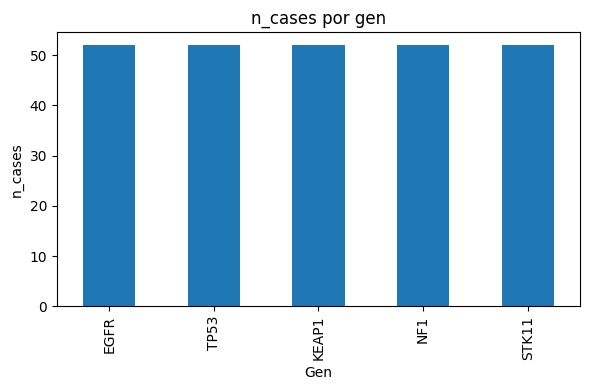

[OK] Guardada figura de métricas: /home/rapids/notebooks/slima/MAF/xgb_results/metrics_n_cases.png


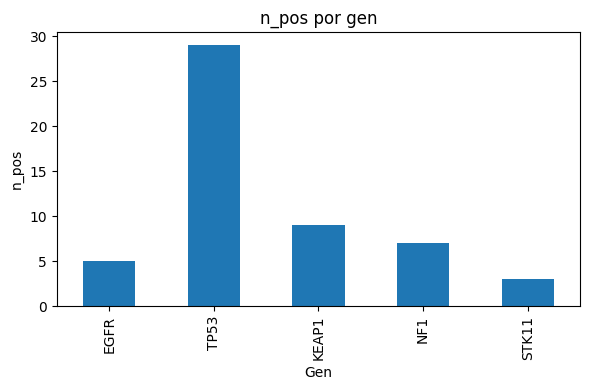

[OK] Guardada figura de métricas: /home/rapids/notebooks/slima/MAF/xgb_results/metrics_n_pos.png


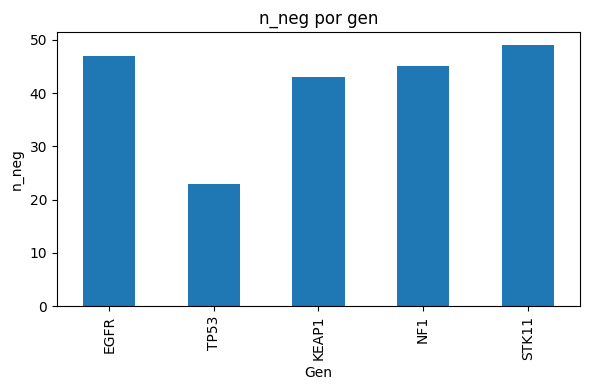

[OK] Guardada figura de métricas: /home/rapids/notebooks/slima/MAF/xgb_results/metrics_n_neg.png


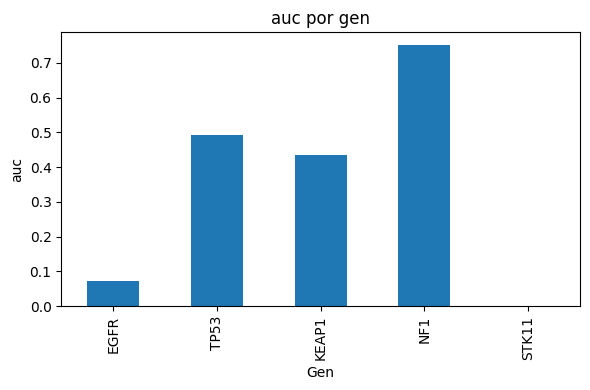

[OK] Guardada figura de métricas: /home/rapids/notebooks/slima/MAF/xgb_results/metrics_auc.png


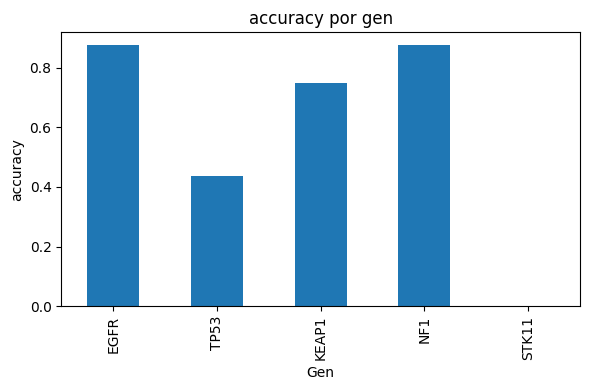

[OK] Guardada figura de métricas: /home/rapids/notebooks/slima/MAF/xgb_results/metrics_accuracy.png


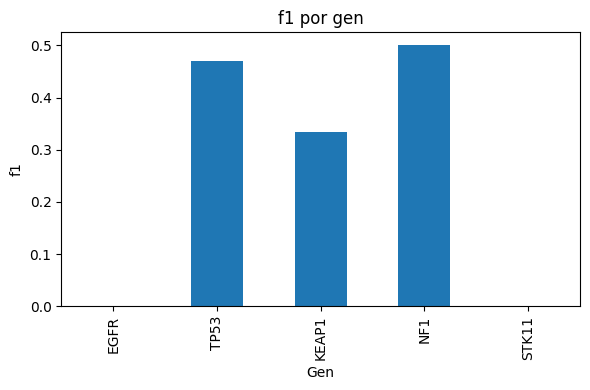

[OK] Guardada figura de métricas: /home/rapids/notebooks/slima/MAF/xgb_results/metrics_f1.png


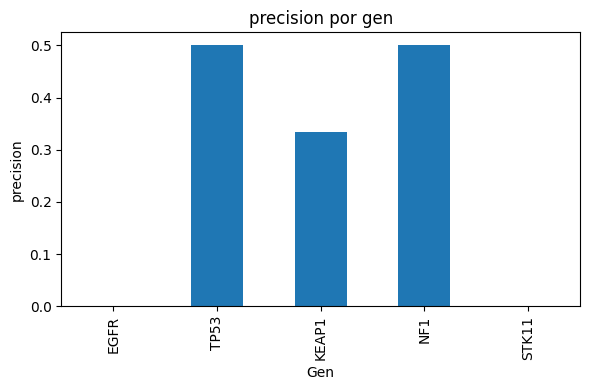

[OK] Guardada figura de métricas: /home/rapids/notebooks/slima/MAF/xgb_results/metrics_precision.png


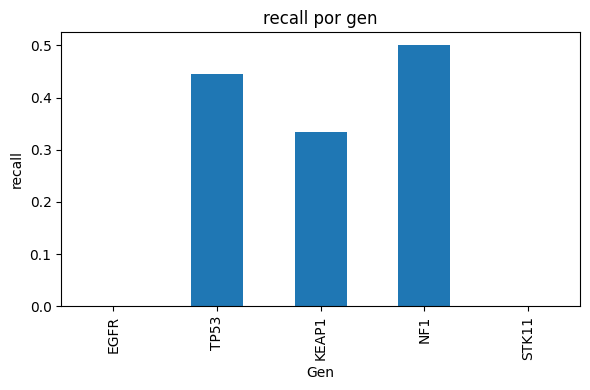

[OK] Guardada figura de métricas: /home/rapids/notebooks/slima/MAF/xgb_results/metrics_recall.png


In [11]:

# -------------------------------------------------------------------
# 1) Visualizar métricas globales por gen (xgb_metrics_all_genes.csv)
# -------------------------------------------------------------------
metrics_path = RESULTS_DIR / "xgb_metrics_all_genes.csv"
if metrics_path.exists():
    df_metrics = pd.read_csv(metrics_path)
    print("[INFO] Métricas leídas de:", metrics_path)
    display(df_metrics.head())

    # Detectar columnas numéricas de métricas (ej. roc_auc, accuracy, f1, etc.)
    metric_cols = [
        c for c in df_metrics.columns
        if c not in ["gene"] and pd.api.types.is_numeric_dtype(df_metrics[c])
    ]

    for mc in metric_cols:
        plt.figure(figsize=(6, 4))
        subset = df_metrics.set_index("gene")[mc]
        subset.plot(kind="bar")
        plt.title(f"{mc} por gen")
        plt.ylabel(mc)
        plt.xlabel("Gen")
        plt.tight_layout()

        out_png = RESULTS_DIR / f"metrics_{mc}.png"
        plt.savefig(out_png, dpi=150)
        plt.show()
        print(f"[OK] Guardada figura de métricas: {out_png}")
else:
    print("[WARN] No se encontró xgb_metrics_all_genes.csv en", RESULTS_DIR)



[INFO] Gráfica de importancias para gen: EGFR
[INFO] Importancias de EGFR leídas de: /home/rapids/notebooks/slima/MAF/xgb_results/xgb_importances_EGFR.csv


,feature,importance
0,pct_micropapillary,0.220255
1,pct_mucinous,0.187661
2,pct_solid,0.163385
3,n_tiles_total,0.144569
4,pct_papillary,0.130171


[INFO] Usando columna de importancia 'importance' para EGFR


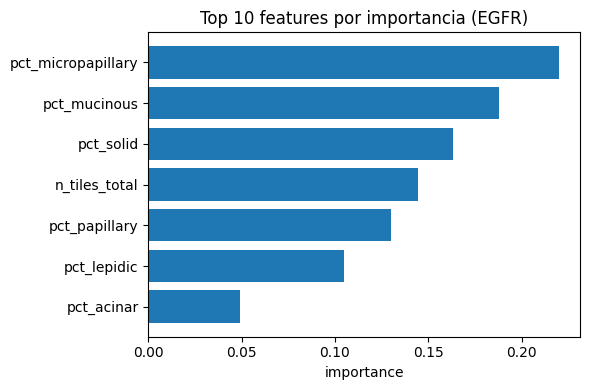

[OK] Guardada figura de importancias de features para EGFR: /home/rapids/notebooks/slima/MAF/xgb_results/feature_importances_EGFR.png

[INFO] Gráfica de importancias para gen: TP53
[INFO] Importancias de TP53 leídas de: /home/rapids/notebooks/slima/MAF/xgb_results/xgb_importances_TP53.csv


,feature,importance
0,pct_papillary,0.246067
1,pct_lepidic,0.207253
2,pct_mucinous,0.137056
3,pct_acinar,0.128010
4,n_tiles_total,0.105373


[INFO] Usando columna de importancia 'importance' para TP53


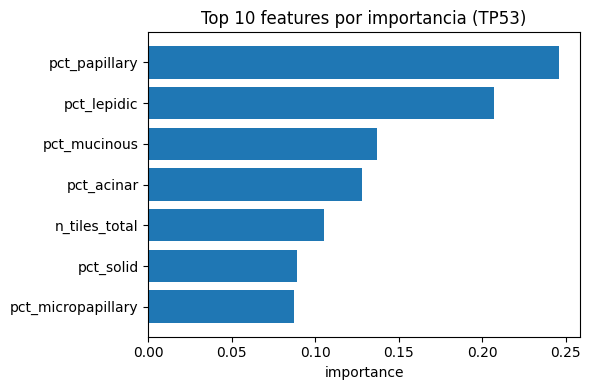

[OK] Guardada figura de importancias de features para TP53: /home/rapids/notebooks/slima/MAF/xgb_results/feature_importances_TP53.png

[INFO] Gráfica de importancias para gen: KEAP1
[INFO] Importancias de KEAP1 leídas de: /home/rapids/notebooks/slima/MAF/xgb_results/xgb_importances_KEAP1.csv


,feature,importance
0,pct_micropapillary,0.188242
1,pct_mucinous,0.186398
2,pct_solid,0.168556
3,pct_papillary,0.145875
4,pct_acinar,0.112025


[INFO] Usando columna de importancia 'importance' para KEAP1


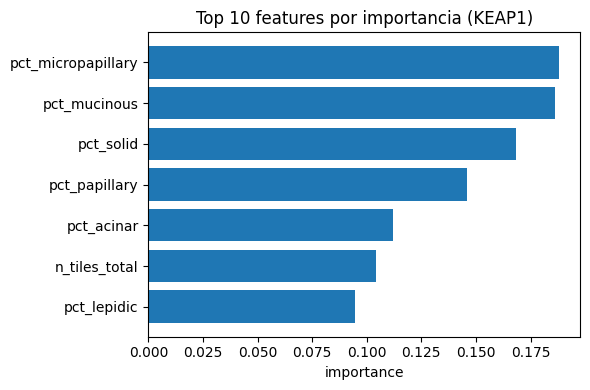

[OK] Guardada figura de importancias de features para KEAP1: /home/rapids/notebooks/slima/MAF/xgb_results/feature_importances_KEAP1.png

[INFO] Gráfica de importancias para gen: NF1
[INFO] Importancias de NF1 leídas de: /home/rapids/notebooks/slima/MAF/xgb_results/xgb_importances_NF1.csv


,feature,importance
0,pct_solid,0.240739
1,n_tiles_total,0.180851
2,pct_mucinous,0.165435
3,pct_papillary,0.138772
4,pct_micropapillary,0.114461


[INFO] Usando columna de importancia 'importance' para NF1


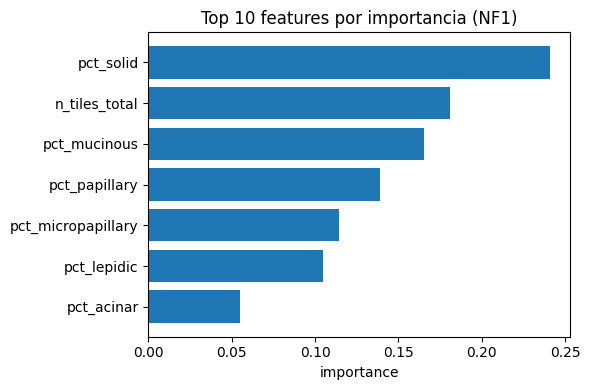

[OK] Guardada figura de importancias de features para NF1: /home/rapids/notebooks/slima/MAF/xgb_results/feature_importances_NF1.png

[INFO] Gráfica de importancias para gen: STK11
[INFO] Importancias de STK11 leídas de: /home/rapids/notebooks/slima/MAF/xgb_results/xgb_importances_STK11.csv


,feature,importance
0,pct_papillary,0.251714
1,pct_micropapillary,0.250545
2,pct_mucinous,0.133528
3,pct_solid,0.103971
4,pct_acinar,0.102277


[INFO] Usando columna de importancia 'importance' para STK11


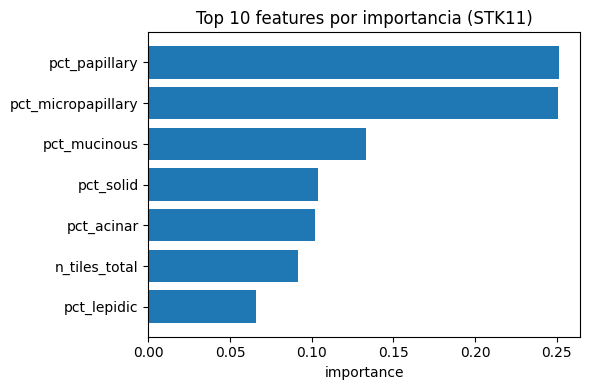

[OK] Guardada figura de importancias de features para STK11: /home/rapids/notebooks/slima/MAF/xgb_results/feature_importances_STK11.png


In [12]:

# -------------------------------------------------------------------
# 2) Visualizar importancias de features por gen (xgb_importances_*.csv)
# -------------------------------------------------------------------
def plot_feature_importances_for_gene(gene: str, top_n: int = 10):
    imp_path = RESULTS_DIR / f"xgb_importances_{gene}.csv"
    if not imp_path.exists():
        print(f"[WARN] No se encontró importances para {gene} -> {imp_path}")
        return

    df_imp = pd.read_csv(imp_path)
    print(f"[INFO] Importancias de {gene} leídas de:", imp_path)
    display(df_imp.head())

    # Intentar detectar columna de importancia numérica
    # Nos quedamos con columnas numéricas excepto el índice/feature
    numeric_cols = [
        c for c in df_imp.columns
        if c not in ["feature", "feat", "name"] and pd.api.types.is_numeric_dtype(df_imp[c])
    ]
    if not numeric_cols:
        print(f"[WARN] No se encontraron columnas numéricas de importancia para {gene}")
        return

    # Tomar la primera métrica numérica como principal
    imp_col = numeric_cols[0]
    print(f"[INFO] Usando columna de importancia '{imp_col}' para {gene}")

    # Determinar la columna con el nombre de la feature
    if "feature" in df_imp.columns:
        feat_col = "feature"
    elif "feat" in df_imp.columns:
        feat_col = "feat"
    elif "name" in df_imp.columns:
        feat_col = "name"
    else:
        # Si no hay nombre claro, usar la primera columna no numérica
        non_numeric = [c for c in df_imp.columns if c not in numeric_cols]
        if not non_numeric:
            print(f"[WARN] No hay columna obvia de 'feature' para {gene}")
            return
        feat_col = non_numeric[0]

    df_imp_sorted = df_imp.sort_values(by=imp_col, ascending=False).head(top_n)

    plt.figure(figsize=(6, 4))
    plt.barh(df_imp_sorted[feat_col], df_imp_sorted[imp_col])
    plt.gca().invert_yaxis()
    plt.xlabel(imp_col)
    plt.title(f"Top {top_n} features por importancia ({gene})")
    plt.tight_layout()

    out_png = RESULTS_DIR / f"feature_importances_{gene}.png"
    plt.savefig(out_png, dpi=150)
    plt.show()
    print(f"[OK] Guardada figura de importancias de features para {gene}: {out_png}")

for g in GENES:
    print("\n" + "=" * 70)
    print(f"[INFO] Gráfica de importancias para gen: {g}")
    print("=" * 70)
    plot_feature_importances_for_gene(g)



In [13]:
# -------------------------------------------------------------------
# 3) Visualizar resumen SHAP por gen (shap_summary_*.csv)
# -------------------------------------------------------------------
def plot_shap_summary_for_gene(gene: str, top_n: int = 10):
    shap_path = RESULTS_DIR / f"shap_summary_{gene}.csv"
    if not shap_path.exists():
        print(f"[WARN] No se encontró shap_summary para {gene} -> {shap_path}")
        return

    df_shap = pd.read_csv(shap_path)
    print(f"[INFO] SHAP summary de {gene} leído de:", shap_path)
    display(df_shap.head())

    # Buscar columnas numéricas (ej. mean_abs_shap, mean_shap, etc.)
    numeric_cols = [
        c for c in df_shap.columns
        if c not in ["feature", "feat", "name"] and pd.api.types.is_numeric_dtype(df_shap[c])
    ]
    if not numeric_cols:
        print(f"[WARN] No se encontraron columnas numéricas de SHAP para {gene}")
        return

    shap_col = numeric_cols[0]
    print(f"[INFO] Usando columna SHAP '{shap_col}' para {gene}")

    # Columna de nombre de feature
    if "feature" in df_shap.columns:
        feat_col = "feature"
    elif "feat" in df_shap.columns:
        feat_col = "feat"
    elif "name" in df_shap.columns:
        feat_col = "name"
    else:
        non_numeric = [c for c in df_shap.columns if c not in numeric_cols]
        if not non_numeric:
            print(f"[WARN] No hay columna obvia de 'feature' en SHAP para {gene}")
            return
        feat_col = non_numeric[0]

    df_shap_sorted = df_shap.sort_values(by=shap_col, ascending=False).head(top_n)

    plt.figure(figsize=(6, 4))
    plt.barh(df_shap_sorted[feat_col], df_shap_sorted[shap_col])
    plt.gca().invert_yaxis()
    plt.xlabel(shap_col)
    plt.title(f"Top {top_n} features por |SHAP| medio ({gene})")
    plt.tight_layout()

    out_png = RESULTS_DIR / f"shap_summary_{gene}.png"
    plt.savefig(out_png, dpi=150)
    plt.show()
    print(f"[OK] Guardada figura SHAP para {gene}: {out_png}")



[INFO] Gráfica SHAP summary para gen: EGFR
[INFO] SHAP summary de EGFR leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_EGFR.csv


,feature,mean_abs_shap
0,n_tiles_total,2.124604
1,pct_mucinous,1.047236
2,pct_solid,0.911367
3,pct_micropapillary,0.503375
4,pct_lepidic,0.450255


[INFO] Usando columna SHAP 'mean_abs_shap' para EGFR


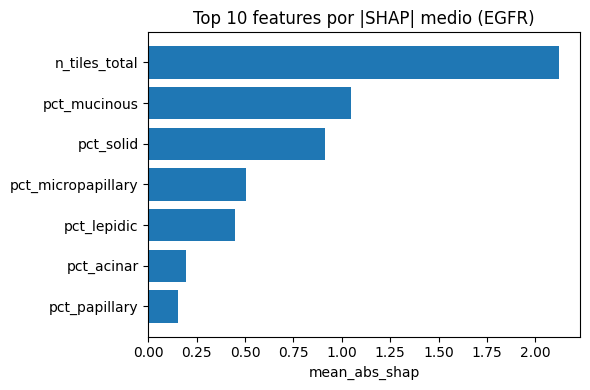

[OK] Guardada figura SHAP para EGFR: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_EGFR.png

[INFO] Gráfica SHAP summary para gen: TP53
[INFO] SHAP summary de TP53 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_TP53.csv


,feature,mean_abs_shap
0,pct_papillary,1.225584
1,pct_lepidic,0.713437
2,pct_acinar,0.626442
3,pct_mucinous,0.406272
4,n_tiles_total,0.361805


[INFO] Usando columna SHAP 'mean_abs_shap' para TP53


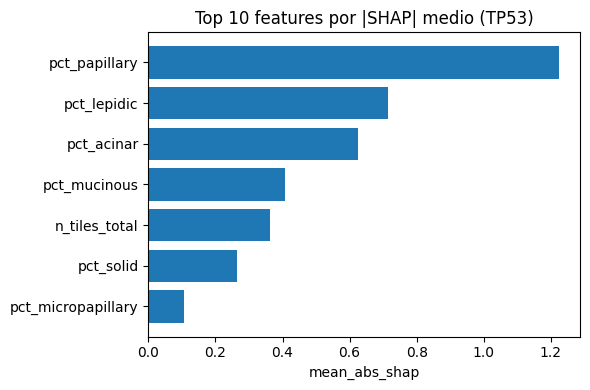

[OK] Guardada figura SHAP para TP53: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_TP53.png

[INFO] Gráfica SHAP summary para gen: KEAP1
[INFO] SHAP summary de KEAP1 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_KEAP1.csv


,feature,mean_abs_shap
0,pct_micropapillary,1.143100
1,pct_mucinous,0.722795
2,pct_solid,0.656705
3,pct_papillary,0.647867
4,pct_acinar,0.515016


[INFO] Usando columna SHAP 'mean_abs_shap' para KEAP1


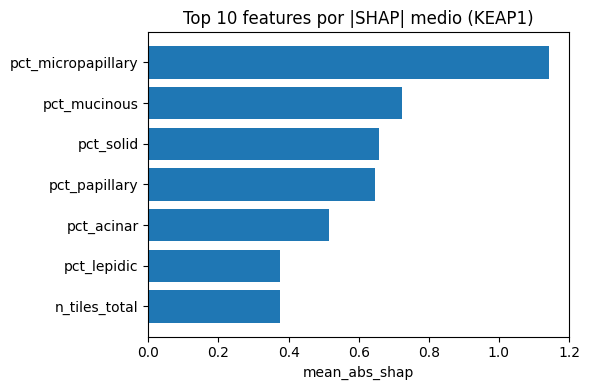

[OK] Guardada figura SHAP para KEAP1: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_KEAP1.png

[INFO] Gráfica SHAP summary para gen: NF1
[INFO] SHAP summary de NF1 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_NF1.csv


,feature,mean_abs_shap
0,n_tiles_total,1.440302
1,pct_mucinous,1.152883
2,pct_lepidic,1.088764
3,pct_solid,0.627335
4,pct_papillary,0.480684


[INFO] Usando columna SHAP 'mean_abs_shap' para NF1


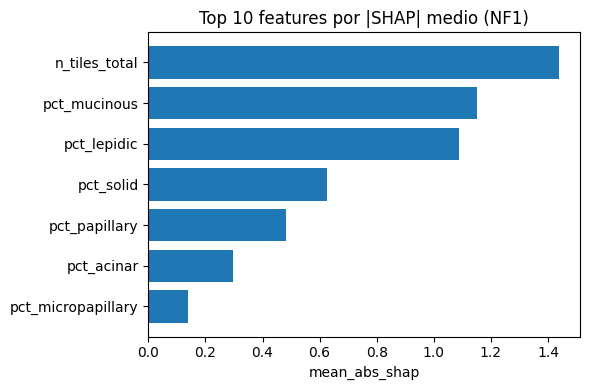

[OK] Guardada figura SHAP para NF1: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_NF1.png

[INFO] Gráfica SHAP summary para gen: STK11
[INFO] SHAP summary de STK11 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_STK11.csv


,feature,mean_abs_shap
0,pct_mucinous,0.124791
1,pct_acinar,0.089615
2,pct_solid,0.074234
3,pct_micropapillary,0.050494
4,pct_papillary,0.044397


[INFO] Usando columna SHAP 'mean_abs_shap' para STK11


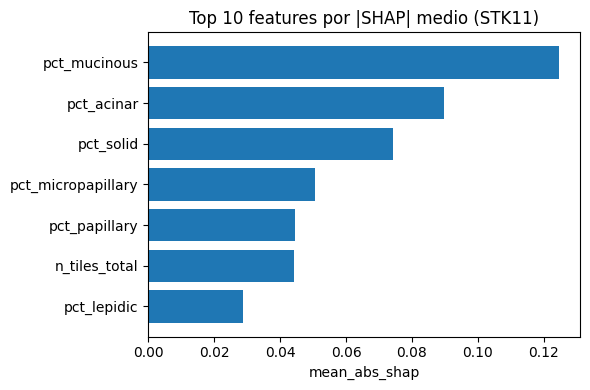

[OK] Guardada figura SHAP para STK11: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_STK11.png

[OK] Todas las figuras han sido generadas y guardadas en: /home/rapids/notebooks/slima/MAF/xgb_results


In [14]:

for g in GENES:
    print("\n" + "=" * 70)
    print(f"[INFO] Gráfica SHAP summary para gen: {g}")
    print("=" * 70)
    plot_shap_summary_for_gene(g)

print("\n[OK] Todas las figuras han sido generadas y guardadas en:", RESULTS_DIR)


In [15]:
HISTO_FEATURES = [
    "n_tiles_total",
    "pct_acinar",
    "pct_lepidic",
    "pct_micropapillary",
    "pct_mucinous",
    "pct_papillary",
    "pct_solid",
]


In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import shap
from pathlib import Path

# RESULTS_DIR ya debería estar definido arriba:
# RESULTS_DIR = Path("/home/rapids/notebooks/slima/MAF/xgb_results")

def plot_shap_summary_for_gene(gene: str, top_n: int = 10):
    """
    - Sigue leyendo shap_summary_{gene}.csv y dibuja el bar chart (como antes).
    - Además:
        * Carga shap_values_{gene}.csv + histo_per_case.csv
        * Genera un SHAP summary real (beeswarm)
        * Genera un SHAP force plot para un caso TCGA (idealmente mutado en ese gen)
    """

    # ------------------------------------------------------------------
    # 1) Lo que YA HACÍAS: leer shap_summary_{gene}.csv y bar chart
    # ------------------------------------------------------------------
    shap_path = RESULTS_DIR / f"shap_summary_{gene}.csv"
    if not shap_path.exists():
        print(f"[WARN] No se encontró shap_summary para {gene} -> {shap_path}")
    else:
        df_shap = pd.read_csv(shap_path)
        print(f"[INFO] SHAP summary de {gene} leído de:", shap_path)
        display(df_shap.head())

        # Buscar columnas numéricas (ej. mean_abs_shap, mean_shap, etc.)
        numeric_cols = [
            c for c in df_shap.columns
            if c not in ["feature", "feat", "name"] and pd.api.types.is_numeric_dtype(df_shap[c])
        ]
        if not numeric_cols:
            print(f"[WARN] No se encontraron columnas numéricas de SHAP para {gene}")
        else:
            shap_col = numeric_cols[0]
            print(f"[INFO] Usando columna SHAP '{shap_col}' para {gene}")

            # Columna de nombre de feature
            if "feature" in df_shap.columns:
                feat_col = "feature"
            elif "feat" in df_shap.columns:
                feat_col = "feat"
            elif "name" in df_shap.columns:
                feat_col = "name"
            else:
                non_numeric = [c for c in df_shap.columns if c not in numeric_cols]
                if not non_numeric:
                    print(f"[WARN] No hay columna obvia de 'feature' en SHAP para {gene}")
                    feat_col = None
                else:
                    feat_col = non_numeric[0]

            if feat_col is not None:
                df_shap_sorted = df_shap.sort_values(by=shap_col, ascending=False).head(top_n)

                plt.figure(figsize=(6, 4))
                plt.barh(df_shap_sorted[feat_col], df_shap_sorted[shap_col])
                plt.gca().invert_yaxis()
                plt.xlabel(shap_col)
                plt.title(f"Top {top_n} features por |SHAP| medio ({gene})")
                plt.tight_layout()

                out_png = RESULTS_DIR / f"shap_summary_bar_{gene}.png"
                plt.savefig(out_png, dpi=150)
                plt.show()
                print(f"[OK] Guardada figura BAR SHAP para {gene}: {out_png}")

    # ------------------------------------------------------------------
    # 2) NUEVO: SHAP REAL (beeswarm global + force plot individual)
    # ------------------------------------------------------------------
    # a) Cargar shap_values_{gene}.csv
    shap_values_path = RESULTS_DIR / f"shap_values_{gene}.csv"
    if not shap_values_path.exists():
        print(f"[WARN] No se encontró shap_values para {gene} -> {shap_values_path}")
        return

    df_sv = pd.read_csv(shap_values_path)
    print(f"[INFO] SHAP values de {gene} leído de:", shap_values_path)

    # Identificar columna de caso (asumimos 'case_barcode', que es lo que usamos en el pipeline)
    case_col_sv = None
    for cand in ["case_barcode", "case_id", "Tumor_Sample_Barcode"]:
        if cand in df_sv.columns:
            case_col_sv = cand
            break
    if case_col_sv is None:
        # fallback: primera columna no numérica
        non_num = [c for c in df_sv.columns if not pd.api.types.is_numeric_dtype(df_sv[c])]
        case_col_sv = non_num[0] if non_num else df_sv.columns[0]

    # b) Cargar tabla histológica por caso
    histo_path = RESULTS_DIR / "histo_per_case.csv"
    if not histo_path.exists():
        print(f"[WARN] No se encontró histo_per_case.csv -> {histo_path}")
        return

    df_histo = pd.read_csv(histo_path)
    print(f"[INFO] histo_per_case leído de:", histo_path)

    # Identificar columna de caso en histo
    case_col_histo = None
    for cand in ["case_barcode", "case_id", "Tumor_Sample_Barcode"]:
        if cand in df_histo.columns:
            case_col_histo = cand
            break
    if case_col_histo is None:
        non_num = [c for c in df_histo.columns if not pd.api.types.is_numeric_dtype(df_histo[c])]
        case_col_histo = non_num[0] if non_num else df_histo.columns[0]

    # c) Features histológicas que existen en ambos dataframes
    feat_cols = [c for c in HISTO_FEATURES if c in df_sv.columns and c in df_histo.columns]
    if not feat_cols:
        print(f"[WARN] No se encontraron columnas comunes de features entre shap_values y histo_per_case para {gene}")
        return

    # d) Hacemos merge para tener shap (por feature) y valor real de la feature en la misma fila/caso
    df_merged = df_sv[[case_col_sv] + feat_cols].merge(
        df_histo[[case_col_histo] + feat_cols],
        left_on=case_col_sv,
        right_on=case_col_histo,
        suffixes=("_shap", "_feat")
    )

    if df_merged.empty:
        print(f"[WARN] Merge vacío entre shap_values y histo_per_case para {gene}")
        return

    # Matrices para SHAP
    shap_cols = [f"{c}_shap" for c in feat_cols]
    feat_cols_feat = [f"{c}_feat" for c in feat_cols]

    shap_values = df_merged[shap_cols].values
    X_feat = df_merged[feat_cols_feat]
    X_feat.columns = feat_cols  # volver a nombres limpios para el plot

    # ------------------------------------------------------------------
    # 2.1) SHAP SUMMARY BEESWARM (global)
    # ------------------------------------------------------------------
    print(f"[INFO] Generando SHAP summary (beeswarm) para {gene}...")
    shap.initjs()  # por si Visualización JS está activa, aunque guardaremos PNG

    plt.figure(figsize=(7, 5))
    shap.summary_plot(
        shap_values,
        X_feat,
        feature_names=feat_cols,
        show=False
    )
    plt.title(f"SHAP summary (beeswarm) - {gene}")
    plt.tight_layout()

    out_bee = RESULTS_DIR / f"shap_beeswarm_{gene}.png"
    plt.savefig(out_bee, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[OK] SHAP beeswarm guardado en: {out_bee}")

    # ------------------------------------------------------------------
    # 2.2) SHAP INDIVIDUAL PARA 1 CASO TCGA (force plot)
    # ------------------------------------------------------------------
    # Elegimos preferentemente un caso mutado en ese gen (col {gene}_mut en histo_per_case)
    target_col = f"{gene}_mut"
    sample_case = None

    if target_col in df_histo.columns:
        mutated = df_histo[df_histo[target_col] == 1][case_col_histo].astype(str).tolist()
        if mutated:
            sample_case = mutated[0]  # primer caso mutado
            print(f"[INFO] Caso TCGA mutado en {gene} seleccionado: {sample_case}")
        else:
            print(f"[INFO] No hay casos mutados en {gene} en histo_per_case, eligiendo primer caso del merge")
    else:
        print(f"[WARN] No se encontró columna {target_col} en histo_per_case, eligiendo primer caso del merge")

    if sample_case is None:
        sample_case = df_merged[case_col_sv].astype(str).iloc[0]

    # Localizar fila correspondiente en df_merged
    mask_row = df_merged[case_col_sv].astype(str) == str(sample_case)
    if not mask_row.any():
        print(f"[WARN] El caso {sample_case} no está en df_merged, usando la primera fila del merge")
        idx_row = 0
        sample_case = df_merged[case_col_sv].iloc[0]
    else:
        idx_row = df_merged.index[mask_row][0]

    sample_shap = shap_values[idx_row, :]
    sample_feat = X_feat.iloc[idx_row, :]

    print(f"[INFO] Generando SHAP force plot para {gene}, caso {sample_case}, fila idx={idx_row}")

    plt.figure(figsize=(8, 3))
    # base_value lo ponemos en 0.0 ya que aquí solo estamos usando los shap_values pre-computados
    shap.force_plot(
        0.0,
        sample_shap,
        sample_feat,
        matplotlib=True,
        show=False
    )
    plt.title(f"SHAP force plot - {gene} - {sample_case}")
    plt.tight_layout()

    out_force = RESULTS_DIR / f"shap_force_{gene}_{sample_case}.png"
    plt.savefig(out_force, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[OK] SHAP force plot guardado en: {out_force}")


[INFO] SHAP summary de EGFR leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_EGFR.csv


,feature,mean_abs_shap
0,n_tiles_total,2.124604
1,pct_mucinous,1.047236
2,pct_solid,0.911367
3,pct_micropapillary,0.503375
4,pct_lepidic,0.450255


[INFO] Usando columna SHAP 'mean_abs_shap' para EGFR


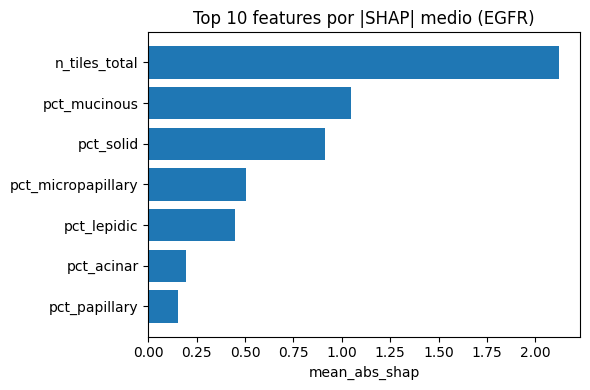

[OK] Guardada figura BAR SHAP para EGFR: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_bar_EGFR.png
[INFO] SHAP values de EGFR leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_values_EGFR.csv
[INFO] histo_per_case leído de: /home/rapids/notebooks/slima/MAF/xgb_results/histo_per_case.csv
[INFO] Generando SHAP summary (beeswarm) para EGFR...


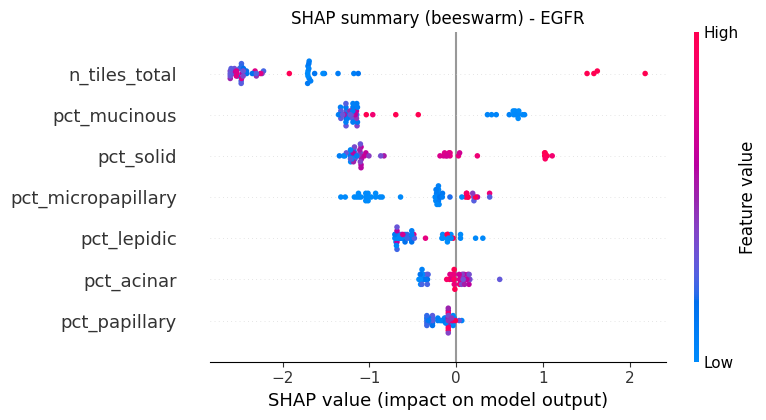

[OK] SHAP beeswarm guardado en: /home/rapids/notebooks/slima/MAF/xgb_results/shap_beeswarm_EGFR.png
[WARN] No se encontró columna EGFR_mut en histo_per_case, eligiendo primer caso del merge
[INFO] Generando SHAP force plot para EGFR, caso TCGA-05-4250, fila idx=0


<Figure size 800x300 with 0 Axes>

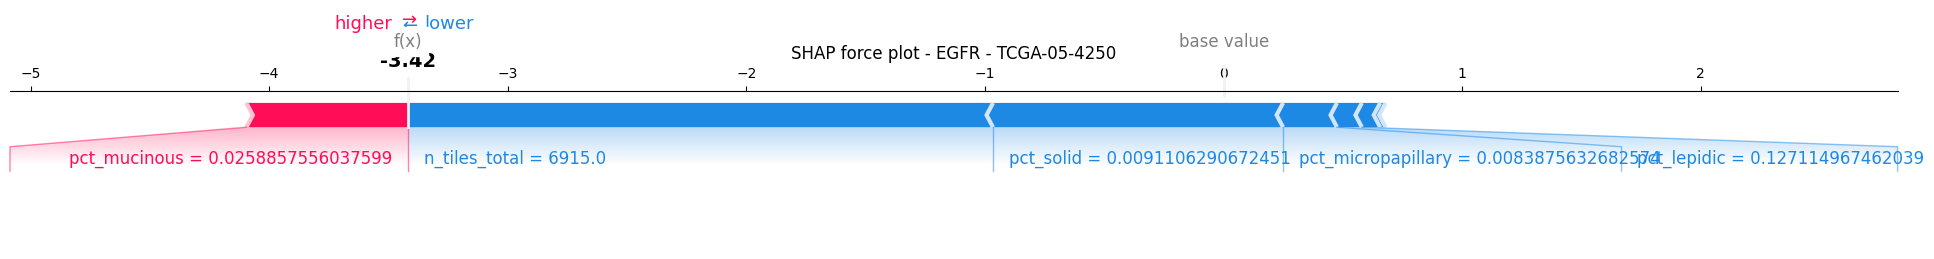

[OK] SHAP force plot guardado en: /home/rapids/notebooks/slima/MAF/xgb_results/shap_force_EGFR_TCGA-05-4250.png


In [17]:
plot_shap_summary_for_gene("EGFR")


[INFO] SHAP summary de TP53 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_TP53.csv


,feature,mean_abs_shap
0,pct_papillary,1.225584
1,pct_lepidic,0.713437
2,pct_acinar,0.626442
3,pct_mucinous,0.406272
4,n_tiles_total,0.361805


[INFO] Usando columna SHAP 'mean_abs_shap' para TP53


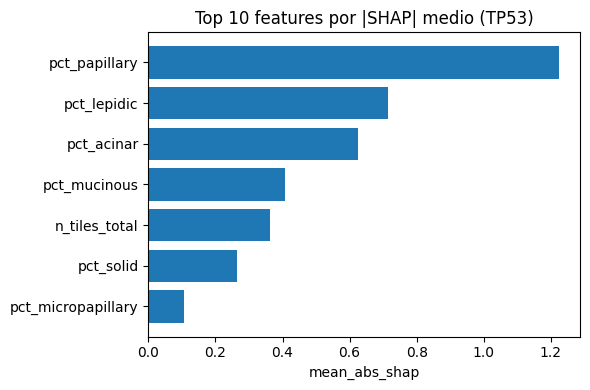

[OK] Guardada figura BAR SHAP para TP53: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_bar_TP53.png
[INFO] SHAP values de TP53 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_values_TP53.csv
[INFO] histo_per_case leído de: /home/rapids/notebooks/slima/MAF/xgb_results/histo_per_case.csv
[INFO] Generando SHAP summary (beeswarm) para TP53...


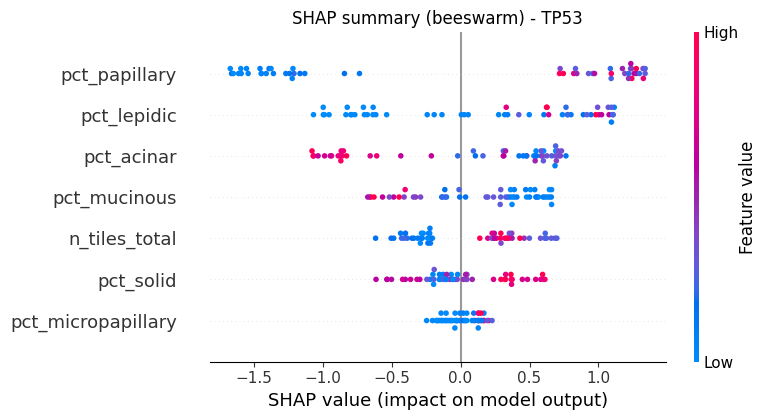

[OK] SHAP beeswarm guardado en: /home/rapids/notebooks/slima/MAF/xgb_results/shap_beeswarm_TP53.png
[WARN] No se encontró columna TP53_mut en histo_per_case, eligiendo primer caso del merge
[INFO] Generando SHAP force plot para TP53, caso TCGA-05-4250, fila idx=0


<Figure size 800x300 with 0 Axes>

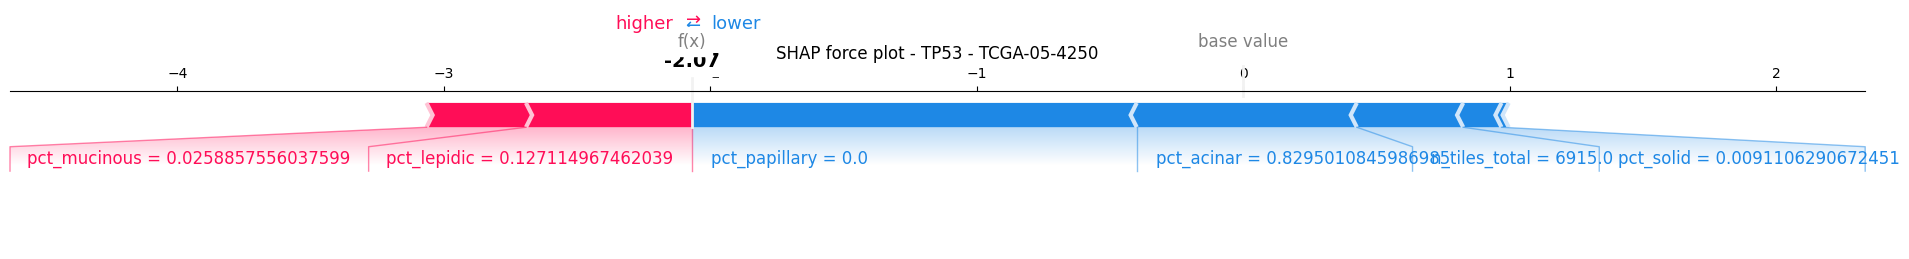

[OK] SHAP force plot guardado en: /home/rapids/notebooks/slima/MAF/xgb_results/shap_force_TP53_TCGA-05-4250.png


In [18]:
plot_shap_summary_for_gene("TP53")


[INFO] SHAP summary de KEAP1 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_KEAP1.csv


,feature,mean_abs_shap
0,pct_micropapillary,1.143100
1,pct_mucinous,0.722795
2,pct_solid,0.656705
3,pct_papillary,0.647867
4,pct_acinar,0.515016


[INFO] Usando columna SHAP 'mean_abs_shap' para KEAP1


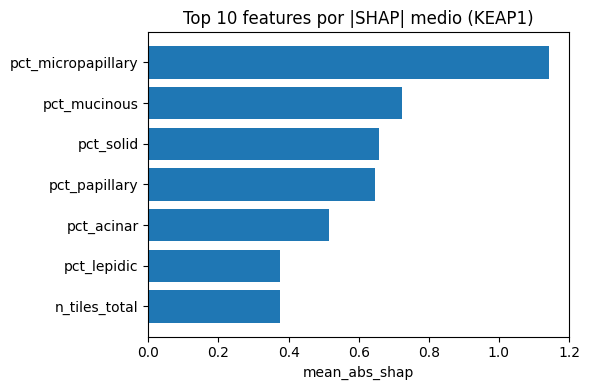

[OK] Guardada figura BAR SHAP para KEAP1: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_bar_KEAP1.png
[INFO] SHAP values de KEAP1 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_values_KEAP1.csv
[INFO] histo_per_case leído de: /home/rapids/notebooks/slima/MAF/xgb_results/histo_per_case.csv
[INFO] Generando SHAP summary (beeswarm) para KEAP1...


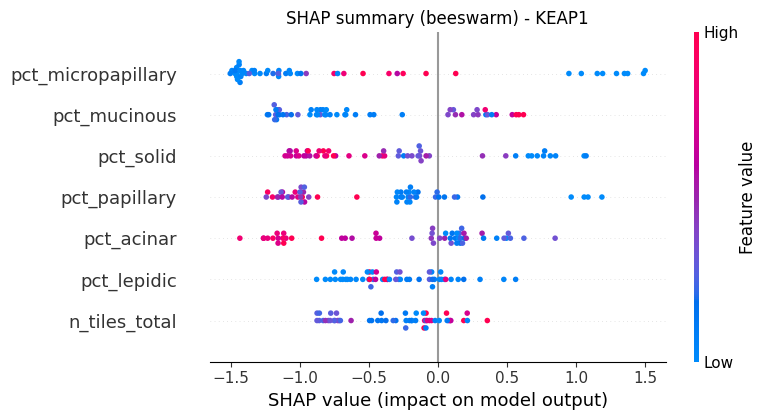

[OK] SHAP beeswarm guardado en: /home/rapids/notebooks/slima/MAF/xgb_results/shap_beeswarm_KEAP1.png
[WARN] No se encontró columna KEAP1_mut en histo_per_case, eligiendo primer caso del merge
[INFO] Generando SHAP force plot para KEAP1, caso TCGA-05-4250, fila idx=0


<Figure size 800x300 with 0 Axes>

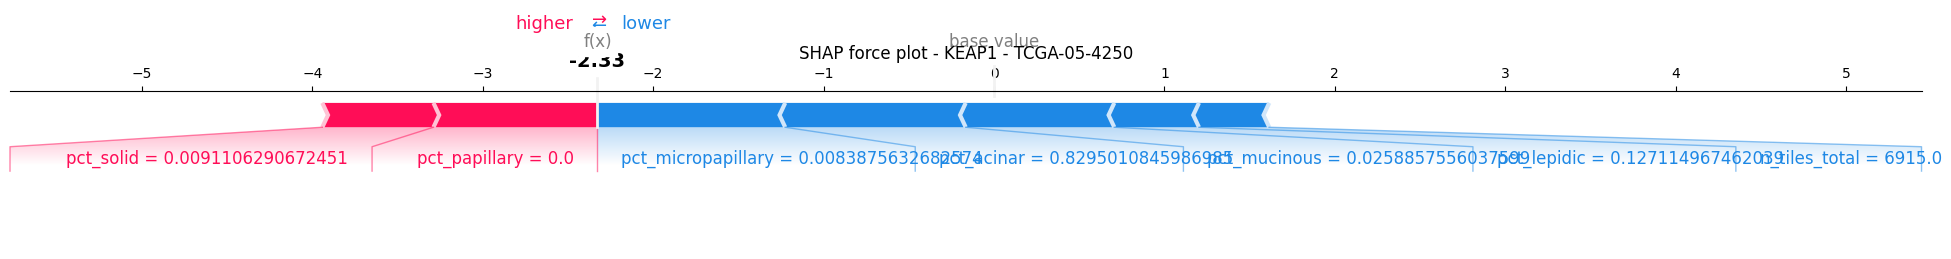

[OK] SHAP force plot guardado en: /home/rapids/notebooks/slima/MAF/xgb_results/shap_force_KEAP1_TCGA-05-4250.png


In [19]:
plot_shap_summary_for_gene("KEAP1")


[INFO] SHAP summary de NF1 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_NF1.csv


,feature,mean_abs_shap
0,n_tiles_total,1.440302
1,pct_mucinous,1.152883
2,pct_lepidic,1.088764
3,pct_solid,0.627335
4,pct_papillary,0.480684


[INFO] Usando columna SHAP 'mean_abs_shap' para NF1


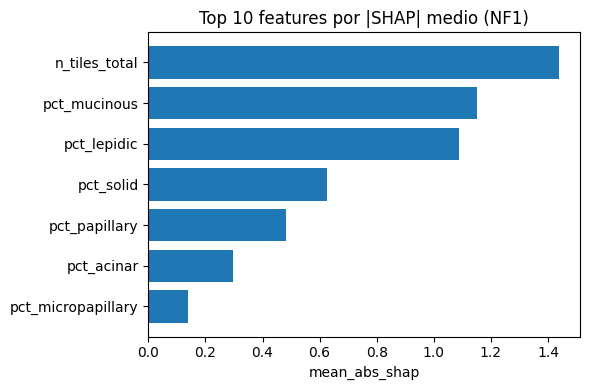

[OK] Guardada figura BAR SHAP para NF1: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_bar_NF1.png
[INFO] SHAP values de NF1 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_values_NF1.csv
[INFO] histo_per_case leído de: /home/rapids/notebooks/slima/MAF/xgb_results/histo_per_case.csv
[INFO] Generando SHAP summary (beeswarm) para NF1...


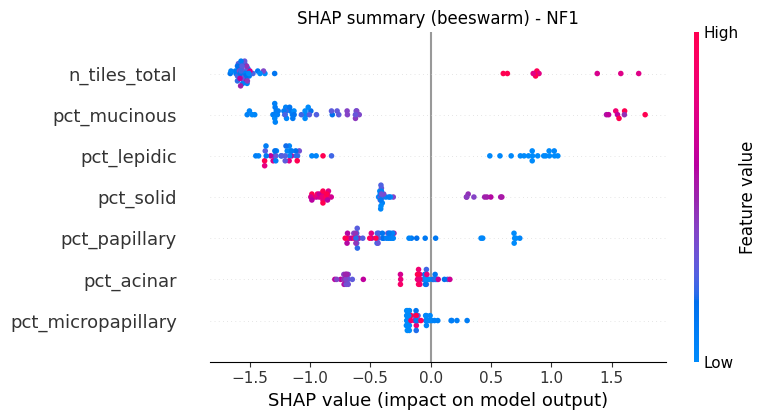

[OK] SHAP beeswarm guardado en: /home/rapids/notebooks/slima/MAF/xgb_results/shap_beeswarm_NF1.png
[WARN] No se encontró columna NF1_mut en histo_per_case, eligiendo primer caso del merge
[INFO] Generando SHAP force plot para NF1, caso TCGA-05-4250, fila idx=0


<Figure size 800x300 with 0 Axes>

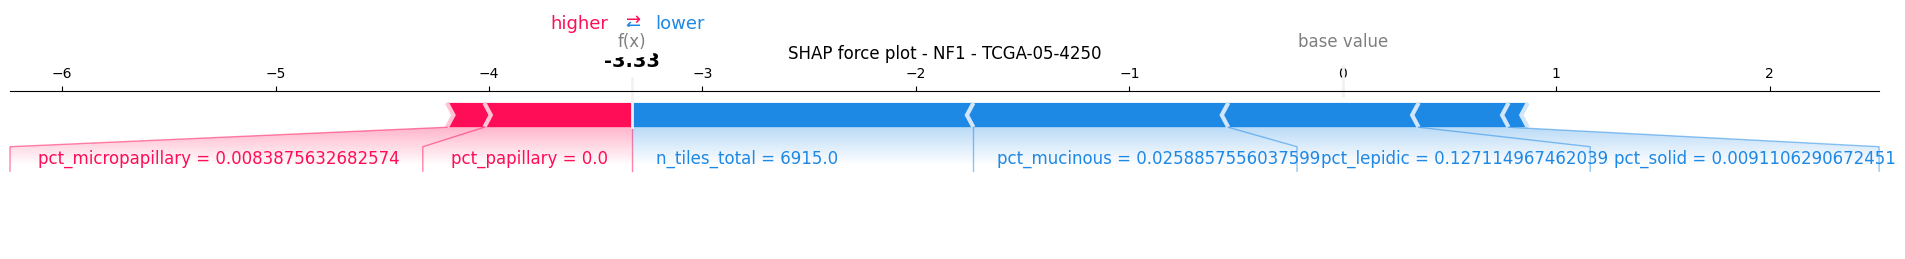

[OK] SHAP force plot guardado en: /home/rapids/notebooks/slima/MAF/xgb_results/shap_force_NF1_TCGA-05-4250.png


In [20]:
plot_shap_summary_for_gene("NF1")


[INFO] SHAP summary de STK11 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_STK11.csv


,feature,mean_abs_shap
0,pct_mucinous,0.124791
1,pct_acinar,0.089615
2,pct_solid,0.074234
3,pct_micropapillary,0.050494
4,pct_papillary,0.044397


[INFO] Usando columna SHAP 'mean_abs_shap' para STK11


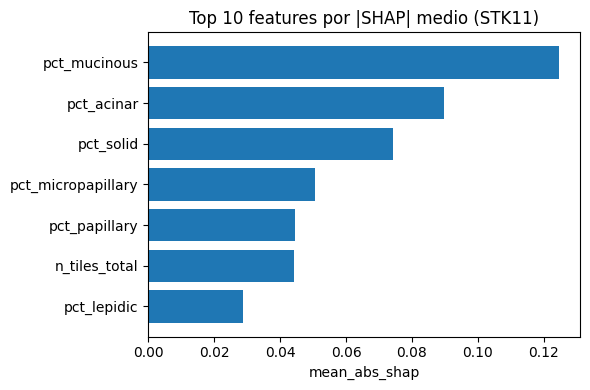

[OK] Guardada figura BAR SHAP para STK11: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_bar_STK11.png
[INFO] SHAP values de STK11 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_values_STK11.csv
[INFO] histo_per_case leído de: /home/rapids/notebooks/slima/MAF/xgb_results/histo_per_case.csv
[INFO] Generando SHAP summary (beeswarm) para STK11...


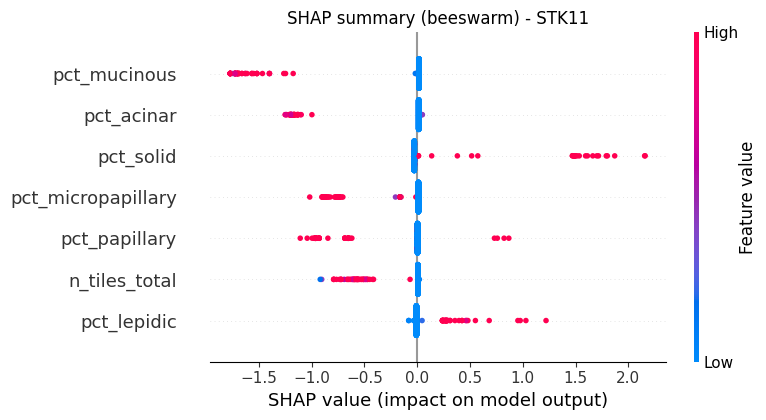

[OK] SHAP beeswarm guardado en: /home/rapids/notebooks/slima/MAF/xgb_results/shap_beeswarm_STK11.png
[WARN] No se encontró columna STK11_mut en histo_per_case, eligiendo primer caso del merge
[INFO] Generando SHAP force plot para STK11, caso 7316UP-219, fila idx=0


<Figure size 800x300 with 0 Axes>

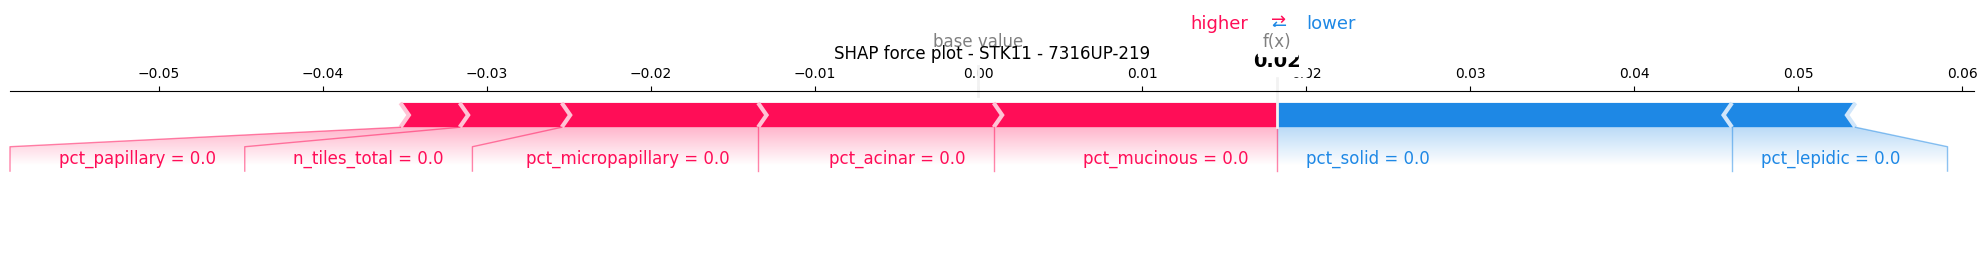

[OK] SHAP force plot guardado en: /home/rapids/notebooks/slima/MAF/xgb_results/shap_force_STK11_7316UP-219.png


In [21]:
plot_shap_summary_for_gene("STK11")
